# India's Agricultural Crop Production Analysis — EDA

This notebook explores the cleaned crop production dataset (1997-2021) and answers questions for all three project scenarios: **Farmer**, **Policy Analyst**, and **Investor**.

> Run `python src/generate_data.py` and `python src/data_preprocessing.py` first if `data/crop_production_clean.csv` doesn't exist yet.

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from data_analysis import *

df = load_clean('../data/crop_production_clean.csv')
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Decade
0,Uttar Pradesh,Kanpur,2008,Kharif,Bajra,28517.7,32977.4,1.156,2000
1,Karnataka,Ballari,2012,Whole Year,Coconut,46739.2,532488.7,11.393,2010
2,Tamil Nadu,Madurai,2010,Autumn,Rice,3185.2,9369.2,2.941,2010
3,Maharashtra,Nashik,2006,Kharif,Jowar,28092.0,28713.4,1.022,2000
4,Gujarat,Ahmedabad,1998,Rabi,Onion,9920.3,182847.2,18.432,1990


In [2]:
df.describe(include='all')

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Decade
count,2587,2587,2587.000000,2587,2587,2587.000000,2.587000e+03,2587.000000,2587.000000
unique,15,60,NaN,5,20,NaN,NaN,NaN,NaN
top,Karnataka,Bengaluru Rural,NaN,Kharif,Rice,NaN,NaN,NaN,NaN
freq,348,89,NaN,1092,595,NaN,NaN,NaN,NaN
mean,NaN,NaN,2008.992269,NaN,NaN,37348.710244,3.774715e+05,8.113935,2004.395052
std,NaN,NaN,7.208846,NaN,NaN,28019.930500,1.002298e+06,15.512792,8.043969
min,NaN,NaN,1997.000000,NaN,NaN,2032.100000,4.820300e+03,0.361000,1990.000000
25%,NaN,NaN,2003.000000,NaN,NaN,14801.250000,2.670190e+04,1.279000,2000.000000
50%,NaN,NaN,2009.000000,NaN,NaN,29303.100000,6.050600e+04,2.506000,2000.000000
75%,NaN,NaN,2015.000000,NaN,NaN,53812.700000,1.572690e+05,3.473000,2010.000000


## Scenario 1 — Farmer: seasonal trends & top crops

In [3]:
top_crops_by_production(df, n=10)

Crop
Sugarcane    3.782825e+08
Banana       2.194025e+08
Onion        1.003053e+08
Potato       9.527897e+07
Coconut      4.726985e+07
Wheat        2.854083e+07
Maize        2.219806e+07
Rice         2.147441e+07
Jute         9.606974e+06
Tobacco      7.374425e+06
Name: Production, dtype: float64

In [4]:
seasonal_trends(df)

,Total_Area,Total_Production,Avg_Yield
Season,,,
Whole Year,16036172.0,6.449548e+08,42.140149
Rabi,33426236.1,2.081958e+08,6.019262
Kharif,43323678.7,1.126396e+08,3.065161
Winter,2331867.7,6.559377e+06,2.795625
Autumn,1503158.9,4.169248e+06,2.768157


## Scenario 2 — Policy Analyst: low-yield regions & long-term trend

In [5]:


state_yield_ranking(df)

State_Name
Rajasthan          1.810740
Haryana            2.047773
Madhya Pradesh     2.063060
Punjab             2.454784
Odisha             2.648970
Assam              2.669110
Andhra Pradesh     5.150722
Bihar              6.946918
West Bengal        7.386528
Kerala             9.129560
Karnataka          9.881601
Uttar Pradesh     10.639318
Gujarat           10.981719
Tamil Nadu        15.836345
Maharashtra       17.479786
Name: Yield, dtype: float64

<Axes: title={'center': 'Total Production by Year'}, xlabel='Crop_Year'>

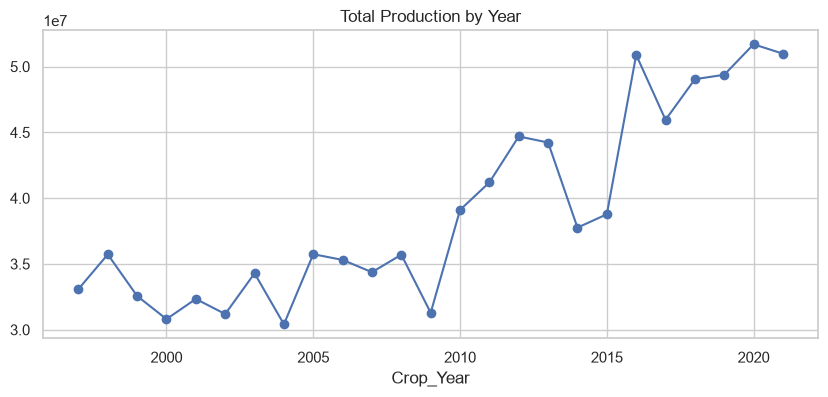

In [6]:
yearly_production_trend(df).plot(marker='o', figsize=(10,4), title='Total Production by Year')

## Scenario 3 — Investor: growth rate & consistency

<Axes: title={'center': 'Crop CAGR 1997-2021 (%)'}>

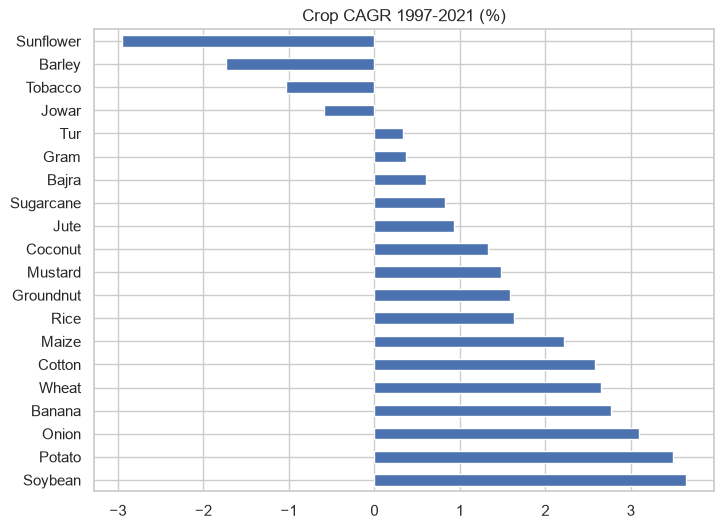

In [7]:
crop_growth_rate(df).plot(kind='barh', figsize=(8,6), title='Crop CAGR 1997-2021 (%)')

In [8]:
consistent_growth_states(df).sort_values('cv').head(10)

,mean,std,cv
State_Name,,,
Haryana,3.133350e+05,4.488861e+04,0.143
Karnataka,8.300828e+06,1.433388e+06,0.173
Odisha,2.284152e+05,4.268342e+04,0.187
Assam,3.426508e+05,6.552296e+04,0.191
Madhya Pradesh,8.109258e+05,1.593325e+05,0.196
Tamil Nadu,3.435203e+06,7.163743e+05,0.209
Punjab,3.163551e+05,6.840164e+04,0.216
Kerala,8.039469e+05,1.772788e+05,0.221
Rajasthan,6.025058e+05,1.338609e+05,0.222
